# Convolutional Neural Networks Tuning

## Data Preparation

In [1]:
from tensorflow.keras.datasets import cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [2]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

## Data Augmentation

In [3]:
from tensorflow.keras import layers, Sequential
import numpy as np

augment_data = Sequential([
    layers.RandomCrop(32, 32),
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.2),
    layers.RandomContrast(0.2),
    layers.RandomZoom(0.15),
    layers.RandomErasing(value_range=(0,1), scale=(0.05, 0.15)),
])

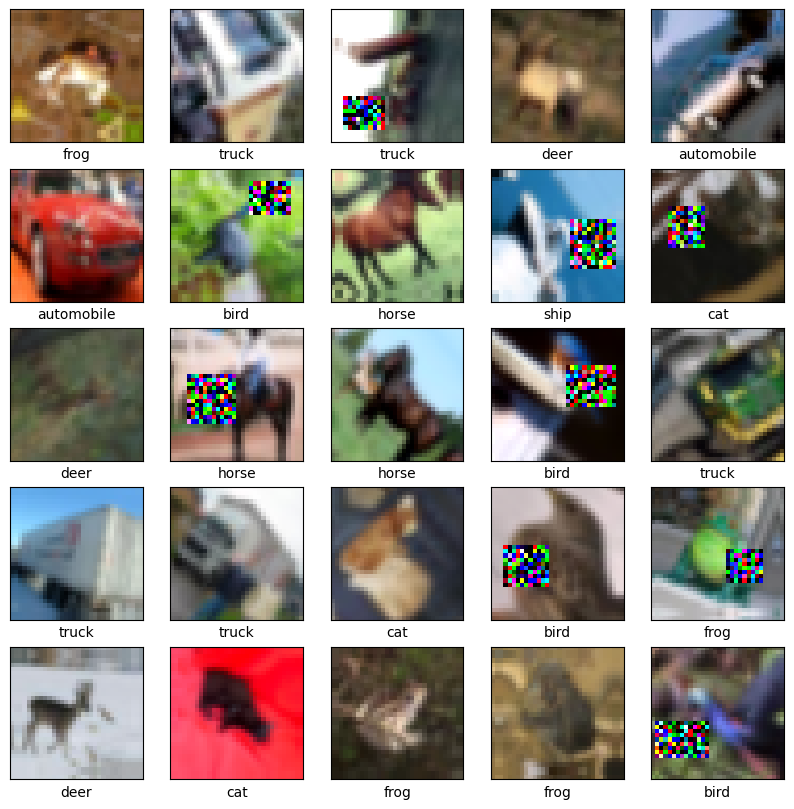

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=[10, 10])

augmented_example = augment_data(x_train[:25])
for i in range(len(augmented_example)):
  plt.subplot(5, 5, i + 1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(np.clip(augmented_example[i], 0, 1), cmap=plt.cm.binary)
  plt.xlabel(class_names[y_train[i][0]])

plt.show()

## Label Encoding

In [5]:
from tensorflow.keras.utils import to_categorical
y_train_encoded = to_categorical(y_train, num_classes=len(class_names))
y_test_encoded = to_categorical(y_test, num_classes=len(class_names))

## Building and Training the Model

In [6]:
from tensorflow.keras import layers, Sequential

num_classes = len(class_names)
input_shape = x_train.shape[1:]

feature_learning = Sequential([
    layers.Input(shape=input_shape),
    augment_data,
    
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),
    
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),
    
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),
])

In [7]:
classification = Sequential([
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax'),
])

In [8]:
model = Sequential([
    feature_learning,
    classification,
])

In [9]:
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
earlystop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
optimizer = AdamW(weight_decay=1e-4)

In [10]:
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train_encoded, epochs=100, batch_size=32, callbacks=[earlystop], validation_split=0.2)

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 73s 57ms/step - accuracy: 0.2489 - loss: 2.2818 - val_accuracy: 0.3561 - val_loss: 1.9020
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 65s 52ms/step - accuracy: 0.4166 - loss: 1.6249 - val_accuracy: 0.4887 - val_loss: 1.4646
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 68s 54ms/step - accuracy: 0.4779 - loss: 1.4545 - val_accuracy: 0.5459 - val_loss: 1.2768
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 65s 52ms/step - accuracy: 0.5255 - loss: 1.3432 - val_accuracy: 0.6143 - val_loss: 1.0896
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 65s 52ms/step - accuracy: 0.5547 - loss: 1.2562 - val_accuracy: 0.5901 - val_loss: 1.2216
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 65s 52ms/step - accuracy: 0.5787 - loss: 1.1962 - val_accuracy: 0.6622 - val_loss: 0.9575
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 66s 53ms/step - accuracy: 0.6048 - loss: 1.1319 - val_accuracy: 0.6442 - val_loss: 1.0216
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 66s 53ms/step - accuracy: 

## Result

In [11]:
from sklearn.metrics import classification_report
import numpy as np
y_pred_probs = model.predict(x_test, verbose=False)
y_pred_labels = np.argmax(y_pred_probs, axis=1)
y_true_labels = np.argmax(y_test_encoded, axis=1)
print(classification_report(y_true_labels, y_pred_labels, target_names=class_names))

              precision    recall  f1-score   support

    airplane       0.80      0.85      0.83      1000
  automobile       0.86      0.95      0.90      1000
        bird       0.74      0.78      0.76      1000
         cat       0.70      0.69      0.70      1000
        deer       0.83      0.75      0.79      1000
         dog       0.82      0.68      0.74      1000
        frog       0.82      0.85      0.84      1000
       horse       0.84      0.86      0.85      1000
        ship       0.91      0.86      0.88      1000
       truck       0.82      0.87      0.84      1000

    accuracy                           0.81     10000
   macro avg       0.81      0.81      0.81     10000
weighted avg       0.81      0.81      0.81     10000



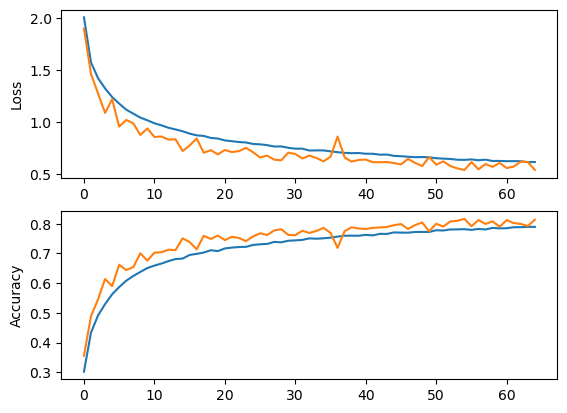

In [12]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(2)

axs[0].plot(history.history['loss'])
axs[0].plot(history.history['val_loss'])
axs[0].set(ylabel='Loss')

axs[1].plot(history.history['accuracy'])
axs[1].plot(history.history['val_accuracy'])
axs[1].set(ylabel='Accuracy')

plt.show()